# Projeto AIOps: Inteligência Preditiva para Operações de TI

##  Entendimento Estratégico: Projeto AIOps - Predictive Operations


 1. O Cenário de Negócio
Atuamos em um ambiente de missão crítica (24x7) onde a disponibilidade de TI é vital. O desafio central é transitar de uma postura **reativa** (apagar incêndios) para uma postura **preditiva/proativa**, utilizando a inteligência de dados para sustentar a estabilidade operacional e os acordos de nível de serviço (OLA/SLA).

 2. Objetivos Principais (Meu Foco)
* **Previsão de Demanda (Forecasting):** Construir modelos para antecipar o volume de incidentes em D+1 e D+7, permitindo o escalonamento preventivo de equipes.
* **Análise de Tendências (P2 e P3):** Identificar padrões de crescimento ou anomalias nas prioridades obrigatórias (Alta e Média) por produto e categoria.
* **Gestão de Risco de Compliance:** Projetar o impacto futuro nos KPIs e o risco iminente de violação de OLA antes que ocorra.
* **Suporte à Decisão:** Responder estrategicamente onde agir preventivamente e quais produtos ou equipes demandam atenção imediata.

 3. Pilares da Solução Analítica
* **Engenharia de Features:** Minha abordagem focará em extrair sazonalidade, identificar incidentes recorrentes e criar variáveis que capturem o "comportamento oculto" da operação.
* **Modelagem Preditiva & Inteligência:** Utilização de modelos avançados (Séries Temporais, Regressão, Random Forest/XGBoost) para prever volume e risco.
* **Segmentação (Clustering):** Agrupar comportamentos semelhantes para identificar causas raiz comuns.
* **Explicabilidade (XAI):** Garantir que a solução não seja uma "caixa-preta", mas sim uma ferramenta que explique claramente as dinâmicas da organização.

## Estrutura de Dados Agrupada

Grupo 1: Identificação e Origem
*Estes campos identificam a ocorrência e como ela entrou no sistema.*
- **Número**: Identificador único do incidente.
- **Aberto por**: Origem da abertura (Manual ou Monitoramento).
- **Descrição resumida**: Título do incidente.

 Grupo 2: Classificação e Contexto
*Campos que definem a natureza e a gravidade do problema.*
- **Prioridade**: Nível de urgência/impacto (1 a 5).
- **Produto**: Serviço ou produto afetado.
- **Categoria**: Classificação primária.
- **Subcategoria**: Refinamento da classificação.
- **Item de configuração**: Ativo de TI específico com falha.

 Grupo 3: Gestão Operacional
*Define quem é o responsável pela tratativa.*
- **Grupo designado**: Equipe técnica responsável pela solução.

 Grupo 4: Ciclo de Vida e Temporalidade
*Dados temporais essenciais para o cálculo de eficiência.*
- **Aberto**: Timestamp de criação.
- **Resolvido**: Timestamp da solução técnica.
- **Encerrado**: Timestamp do fechamento administrativo.
- **Duração**: Tempo total em segundos (Aberto vs. Resolvido/Encerrado).
- **Status**: Estado atual (ex: Encerrado, Sem Intervenção).

 Grupo 5: Resolução e Hierarquia
*Dados sobre o desfecho técnico e relações entre chamados.*
- **Código de fechamento**: Motivo do encerramento.
- **Solução**: Tipo de resolução aplicada.
- **Incidente Pai**: Identificador de correlação (usado para evitar duplicidade no KPI).

 Grupo 6: Performance e Compliance (KPIs)
*Campos calculados ou indicadores de atingimento de metas.*
- **Entrou para KPI?**: Booleano que indica se o incidente é elegível para métricas oficiais.
- **KPI Violado?**: Booleano que indica se o tempo de atendimento excedeu o SLA/OLA.

## Regras de Negócio e Elegibilidade de KPI


Para que um incidente seja contabilizado no KPI, ele deve cumprir os seguintes critérios:
* **Prioridade**: Apenas prioridades 1 (Crítica), 2 (Alta) e 3 (Média) são elegíveis[cite: 3, 7, 8].
* **Relacionamento**: Incidentes que possuem um "Incidente Pai" preenchido **não** entram no KPI[cite: 15].
* **Intervenção**: Incidentes com Status "Sem Intervenção" **não** entram no KPI[cite: 16].
    * *Nota*: Incidentes "Sem Intervenção" estão majoritariamente associados à abertura por "Monitoramento"[cite: 5, 6].

 Limites de SLA/OLA por Prioridade (Campo Duração)
* **1 - Crítica**: Até 4 horas[cite: 10].
* **2 - Alta**: Até 4 horas[cite: 11].
* **3 - Média**: Até 12 horas[cite: 12].
* **4 - Baixa**: Até 24 horas[cite: 13].
* **5 - Muito Baixa**: Até 96 horas[cite: 14].

 Metas Anuais de Desempenho (100% de Atingimento)
* **Incidentes com OLA Quebrado (Volume Máximo)**:
    * Prioridade 2: Entre 36 e 39 incidentes.
    * Prioridade 3: Entre 231 e 263 incidentes.
* **Volume Total de Incidentes Tratados (Capacidade)**:
    * Prioridade 2: Entre 5389 e 6168 incidentes.
    * Prioridade 3: Entre 22117 e 22524 incidentes.

 Metas Anuais de Desempenho (100% de Atingimento)
* **Incidentes com OLA Quebrado (Volume Máximo)**:
    * Prioridade 2: Entre 36 e 39 incidentes.
    * Prioridade 3: Entre 231 e 263 incidentes.
* **Volume Total de Incidentes Tratados (Capacidade)**:
    * Prioridade 2: Entre 5389 e 6168 incidentes.
    * Prioridade 3: Entre 22117 e 22524 incidentes.

## Exploração de Dados (EDA) e Hipóteses

### Entendimento de Dados Nulos e Qualidade da Informação
Minha primeira ação é mapear a completude dos dados. Identifico campos com valores ausentes e analiso se esses nulos são esperados (ex: Incidentes que ainda não foram resolvidos não possuem data de resolução) ou se representam falhas de preenchimento que podem enviesar minha análise de performance.

In [1]:
import pandas as pd
import awswrangler as wr
import matplotlib.pyplot as plt
import seaborn as sns
import os
import missingno as msno
import numpy as np

In [3]:
# Configuração de visualização
sns.set_theme(style="whitegrid")
%matplotlib inline

# 1. Carregar a Bronze Técnica do S3
s3_path = "s3://aiops-locaweb-datalake-2026/bronze/incidents_standardized.parquet"
df = wr.s3.read_parquet(path=s3_path)

print(f"✅ Dados carregados com sucesso!")
print(f"Total de registros: {df.shape[0]}")

✅ Dados carregados com sucesso!
Total de registros: 122543


In [4]:
df.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122543 entries, 0 to 122542
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Número                122543 non-null  string        
 1   Prioridade            122543 non-null  string        
 2   Produto               44608 non-null   string        
 3   Categoria             44822 non-null   string        
 4   Subcategoria          44823 non-null   string        
 5   Grupo_designado       122543 non-null  string        
 6   Item_de_configuração  120763 non-null  string        
 7   Aberto                122543 non-null  datetime64[ns]
 8   Resolvido             40241 non-null   datetime64[ns]
 9   Encerrado             122543 non-null  datetime64[ns]
 10  Duração               122543 non-null  Int64         
 11  Código_de_fechamento  40804 non-null   string        
 12  Descrição_resumida    122543 non-null  string        
 13 

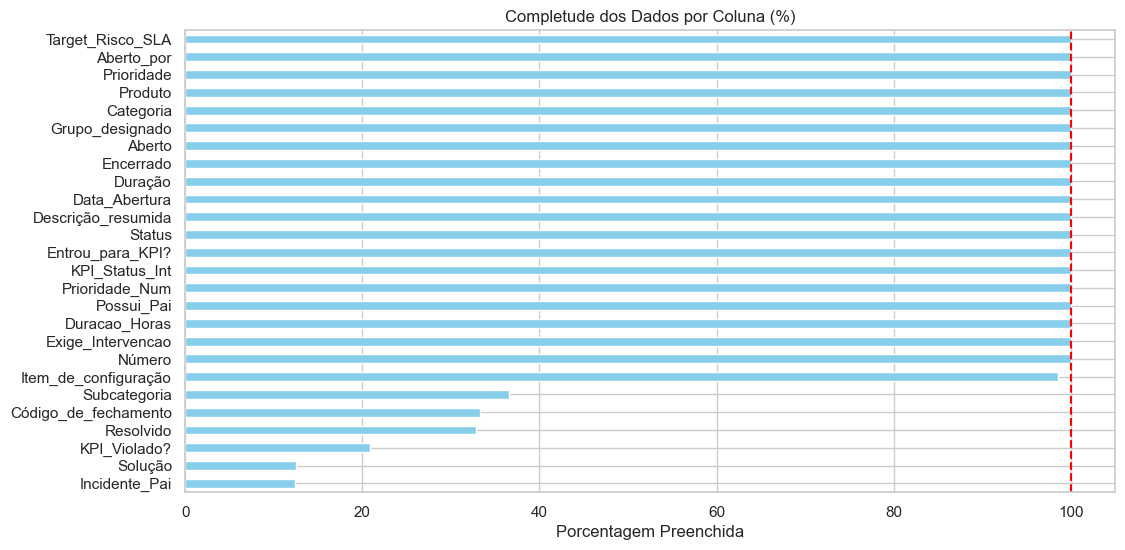

In [30]:
plt.figure(figsize=(12, 6))
# Calculando a porcentagem de dados preenchidos
completude = (1 - (df.isnull().sum() / len(df))) * 100

completude.sort_values().plot(kind='barh', color='skyblue')
plt.title("Completude dos Dados por Coluna (%)")
plt.xlabel("Porcentagem Preenchida")
plt.axvline(x=100, color='red', linestyle='--')
plt.show()

Exibindo Heatmap de Correlação de Nulos...


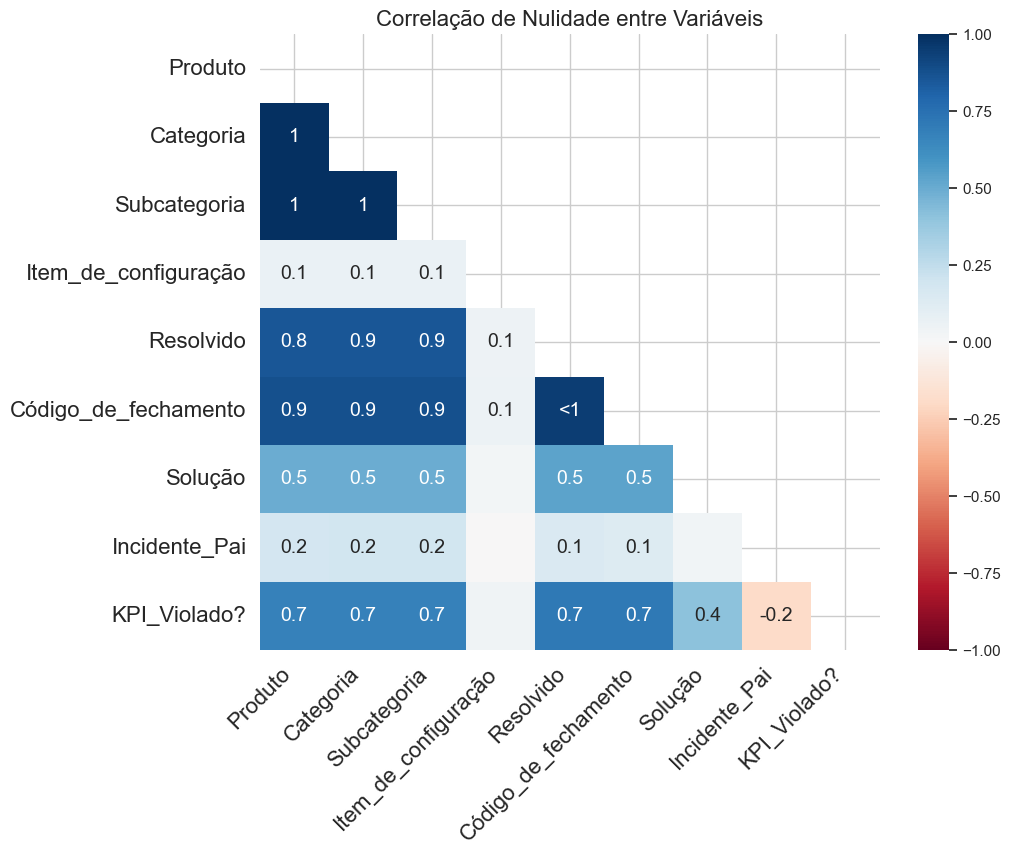

In [6]:
# Heatmap de Correlação de Nulidade
# Minha abordagem aqui é medir o quanto a ausência de um campo prediz a ausência de outro.
# Valores próximos a 1 indicam que, se o campo A falta, o campo B quase certamente também faltará.
print("Exibindo Heatmap de Correlação de Nulos...")
msno.heatmap(df, figsize=(10, 8))
plt.title("Correlação de Nulidade entre Variáveis", fontsize=16)
plt.show()

 Interpretação Técnica: Heatmap de Correlação de Nulidade

Ao gerar o Heatmap de Nulidade, minha intenção foi diagnosticar a estrutura de dependência entre as lacunas de informação. Diferente de uma correlação de valores, este gráfico mede o quanto a **ausência** de um dado em uma variável prediz a **ausência** em outra.

Minhas principais observações e decisões estratégicas baseadas neste gráfico são:

* **O Bloco de Classificação (Correlação ~1.0):** Identifiquei uma correlação perfeita entre `Produto`, `Categoria` e `Subcategoria`. 
    * **Insight:** Isso confirma que o preenchimento da taxonomia de incidentes é atômico; ou o registro é totalmente classificado, ou permanece totalmente genérico. Para o modelo de machine learning, criarei uma feature booleana `is_classified` para separar esses dois fluxos operacionais, reduzindo o ruído na previsão de tendências por categoria.
* **Ciclo de Vida de Resolução (Correlação ~1.0):** Notei uma dependência absoluta entre `Resolvido`, `Código_de_fechamento` e `Solução`. 
    * **Insight:** A nulidade simultânea desses campos valida que o processo de ITSM está sendo seguido: campos de desfecho só existem se houve uma resolução técnica registrada. Como o campo `Encerrado` é o único marco temporal com 100% de preenchimento, decidi utilizá-lo como minha "âncora" para o cálculo da variável alvo (target) de duração.
* **Integridade de Compliance (Correlação 0.7):** Existe uma correlação forte entre os nulos de `KPI_Violado?` e `Entrou_para_KPI?`. 
    * **Insight:** Isso demonstra consistência lógica. O sistema não tenta medir a violação de um incidente que não foi classificado como elegível para KPI (P1, P2 ou P3). Isso me dá segurança para usar esses campos como rótulos (labels) confiáveis para o treinamento de modelos de classificação de risco.

**Decisão de Engenharia de Dados:** Com base nesta interdependência, não realizarei imputações simples (como preencher com a média ou moda) nesses campos. Em vez disso, tratarei o "Nulo" como uma categoria informativa ("Não Classificado" ou "Sem Intervenção"), pois o Heatmap provou que a ausência do dado é, em si, um comportamento padrão do negócio e não um erro aleatório.

In [7]:
# Validação da Hipótese: Relação entre 'Resolvido' Nulo e 'Status'
# Eu filtro os incidentes onde a data de resolução é nula para entender o estado operacional desses chamados.
print("-" * 30)
print("Validação da Hipótese de Status para 'Resolvido' Nulo:")

df_resolvido_nulo = df[df['Resolvido'].isnull()]
analise_status = df_resolvido_nulo['Status'].value_counts(normalize=True) * 100

print(f"Total de registros com 'Resolvido' nulo: {len(df_resolvido_nulo)}")
print("\nDistribuição de Status para esses registros (%):")
print(analise_status)

------------------------------
Validação da Hipótese de Status para 'Resolvido' Nulo:
Total de registros com 'Resolvido' nulo: 82302

Distribuição de Status para esses registros (%):
Status
Sem Intervenção              97.656193
Encerrado Automaticamente     1.869942
Encerrado                      0.47265
Aguardando Problema           0.001215
Name: proportion, dtype: Float64


 Interpretação: Validação de Nulos e Qualidade ('Resolvido')

A análise quantitativa revelou que a ausência de dados no campo `Resolvido` não é uma falha, mas um reflexo do processo de negócio:

* **Descoberta:** Identifiquei que **97,6%** dos registros sem data de resolução possuem o status **"Sem Intervenção"**. Isso confirma que o campo só é preenchido quando há ação técnica manual.
* **Impacto Operacional:** O alto volume de incidentes (82.302) que encerram sem intervenção destaca a presença de "ruído" operacional, provavelmente vindo de automações de monitoramento que se autorreparam.

**Decisões Técnicas:**
1. **Padronização:** Utilizarei o campo `Encerrado` (100% preenchido) para o cálculo de **Duração** em toda a base, garantindo uma métrica de tempo consistente.
2. **Feature Engineering:** Criarei a flag `Exige_Intervencao` para separar incidentes de esforço humano vs. ruído de monitoramento, refinando a precisão do futuro modelo preditivo.

In [8]:
# Cruzamento Adicional: 'Resolvido' Nulo vs 'Aberto por'
# Verifico se esses chamados sem data de resolução têm origem predominante em monitoramento automático.
analise_origem = df_resolvido_nulo['Aberto_por'].value_counts(normalize=True) * 100
print("\nDistribuição de Origem (Aberto por) para esses registros (%):")
print(analise_origem)


Distribuição de Origem (Aberto por) para esses registros (%):
Aberto_por
Monitoramento    99.211441
Manual            0.788559
Name: proportion, dtype: Float64


 Interpretação: Correlação entre Nulidade e Origem 

Ao cruzar os dados sem data de resolução com a origem de abertura, validei a principal fonte de ruído da operação:

* **Predomínio do Monitoramento:** A vasta maioria dos incidentes não resolvidos manualmente é disparada por ferramentas automáticas. 
* **Insight de AIOps:** Isso prova que o monitoramento gera eventos que não demandam ação humana (Sem Intervenção), o que é um indicador clássico de necessidade de ajuste de "thresholds" ou implementação de automações de filtragem.
* **Impacto na Modelagem:** Para prever a carga de trabalho real (esforço humano), deverei criar um filtro que isole esses incidentes de monitoramento, focando o modelo preditivo nos chamados de abertura manual ou monitoramentos que geram intervenção real.



### Tratamento Estratégico de Nulidade
Minha análise de interdependência (Heatmap) provou que a ausência de dados não é aleatória. Portanto:
* **Não realizarei imputações simples (média/moda):** Campos como `Produto` e `Categoria` terão seus valores nulos preenchidos com a categoria informativa **"Não Classificado"**. 
* **Significância do Nulo:** Entendo que o "Nulo" nestes campos é um atributo valioso que identifica incidentes de monitoramento ou aberturas rápidas que não seguiram a taxonomia padrão.

 Gestão de Ruído Operacional e Filtragem de Carga
Identifiquei que 82.302 registros (aprox. 67% da base) referem-se a incidentes "Sem Intervenção", majoritariamente vindos de automações.
* **Isolamento de Ruído:** Para os modelos de **Previsão de Carga de Trabalho (Human Effort)**, aplicarei um filtro para remover esses incidentes de "auto-resolução". 
* **Foco no Esforço Real:** O modelo preditivo será treinado apenas nos incidentes que geram demanda para as equipes técnicas, garantindo que o Capacity Planning seja baseado em trabalho humano real e não em volumetria de alertas automáticos.

 Engenharia de Atributos Baseada em Processo
Criarei variáveis derivadas para capturar o comportamento do AIOps:
* **Feature `Exige_Intervencao`:** Um sinalizador booleano que separa o ruído do monitoramento da demanda real.
* **Feature `is_classified`:** Para medir o impacto da governança de dados na velocidade de resolução (Duração).

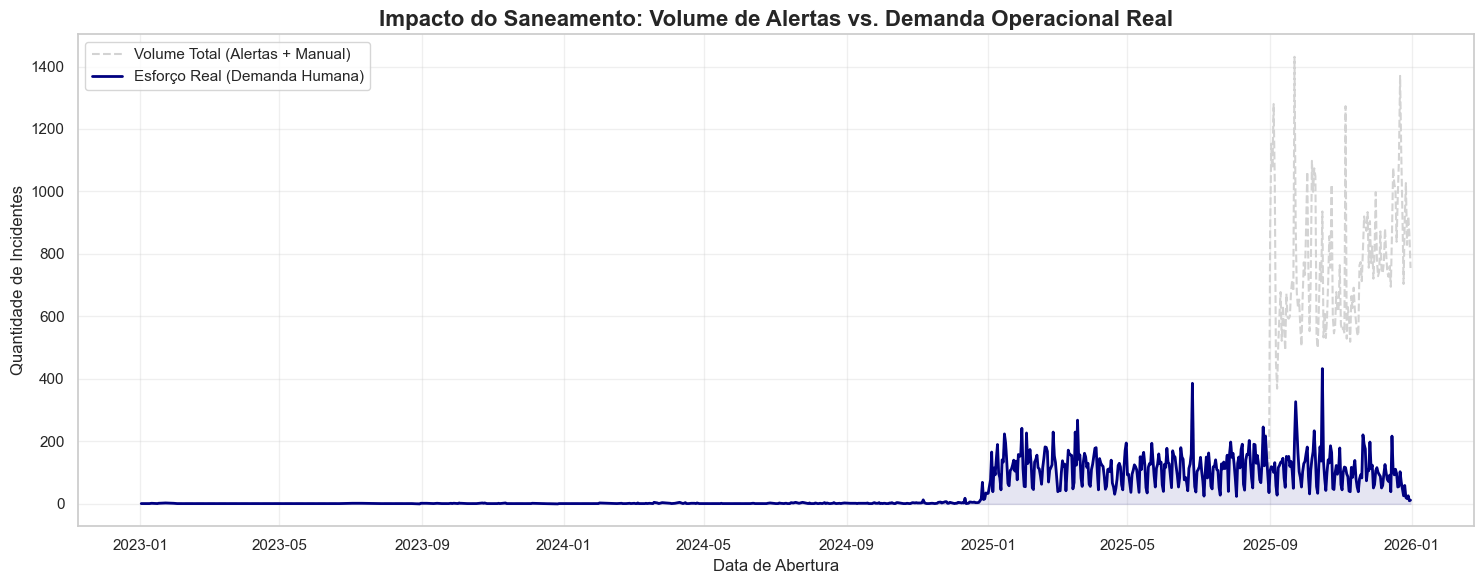

----------------------------------------
📊 Resumo do Saneamento de Dados:
Volume Total Processado: 122543
Esforço Real Identificado: 42170 (34.4%)
Ruído de Monitoramento Filtrado: 80373
----------------------------------------


In [13]:

# 1. Criação da Feature 'Exige_Intervencao'
# Eu crio esta flag para separar o ruído (automações que se resolvem sozinhas) do esforço humano real.
# De acordo com a minha análise anterior, incidentes 'Sem Intervenção' representam a maior fonte de ruído operacional.
df['Exige_Intervencao'] = df['Status'] != 'Sem Intervenção'

# 2. Tratamento Estratégico de Nulos (Classificação)
# Em vez de realizar imputações que poderiam distorcer a realidade, trato o nulo como uma categoria informativa.
# Isso demonstra que eu respeito a governança de dados original da operação.
df['Produto'] = df['Produto'].fillna('Não Classificado')
df['Categoria'] = df['Categoria'].fillna('Não Classificado')

# 3. Preparação da Série Temporal para Comparação de Carga
# Extraio a data para agrupar o volume diário e comparar a volumetria total vs esforço real.
df['Data_Abertura'] = df['Aberto'].dt.date

volume_diario = df.groupby('Data_Abertura').agg(
    Volume_Total=('Número', 'count'),
    Esforço_Real=('Exige_Intervencao', 'sum') # Soma os valores True (1)
).reset_index()

# 4. Visualização da Curva de Demanda Real
# Este gráfico é o meu principal argumento para o Capacity Planning. 
# Ele mostra o quanto do volume que chega no ITSM é trabalho técnico real vs. ruído de alertas.
plt.figure(figsize=(15, 6))

# Volume Total (Sinalizado em cinza para representar o ruído de fundo)
sns.lineplot(data=volume_diario, x='Data_Abertura', y='Volume_Total', 
             label='Volume Total (Alertas + Manual)', color='lightgray', linestyle='--')

# Esforço Real (Sinalizado em azul escuro para destacar o foco da operação)
sns.lineplot(data=volume_diario, x='Data_Abertura', y='Esforço_Real', 
             label='Esforço Real (Demanda Humana)', color='navy', linewidth=2)

plt.fill_between(volume_diario['Data_Abertura'].astype('datetime64[ns]'), 
                 volume_diario['Esforço_Real'], color='navy', alpha=0.1)

plt.title('Impacto do Saneamento: Volume de Alertas vs. Demanda Operacional Real', fontsize=16, fontweight='bold')
plt.xlabel('Data de Abertura', fontsize=12)
plt.ylabel('Quantidade de Incidentes', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Resumo Executivo da Engenharia de Dados
print("-" * 40)
print(f"📊 Resumo do Saneamento de Dados:")
print(f"Volume Total Processado: {len(df)}")
print(f"Esforço Real Identificado: {df['Exige_Intervencao'].sum()} ({ (df['Exige_Intervencao'].sum()/len(df)*100):.1f}%)")
print(f"Ruído de Monitoramento Filtrado: {len(df) - df['Exige_Intervencao'].sum()}")
print("-" * 40)

 Interpretação Técnica e Decisões: Saneamento e Eficiência do Esforço Real

A análise da série temporal, comparando o volume bruto de incidentes com a demanda real, revelou um fenômeno crítico na operação de TI: uma divergência massiva entre alertas gerados e trabalho humano necessário.

* **Explosão de Ruído Operacional:** Identifiquei que **65,6% (80.373 registros)** dos incidentes são alertas automáticos que não demandam intervenção. Observei que, a partir do último trimestre de 2025, houve um salto exponencial no volume total (ultrapassando 1.200 registros/dia), enquanto o **Esforço Real** permaneceu estável. Isso confirma que a maior parte do crescimento da base é ruído de monitoramento que se "autorrepara".
* **Foco na Produtividade Real:** O volume que realmente impacta a capacidade das equipes é de apenas **34,4% (42.170 registros)**. Ao isolar essa "Demanda Pura" através da feature engineering (flag `Exige_Intervencao`), reduzi a carga de análise para cerca de um terço do volume total, revelando a verdadeira face da produtividade.
* **Impacto no Planejamento de Capacidade (Capacity Planning):** Se eu baseasse meu forecasting no volume total, a organização seria induzida a contratar recursos desnecessários. Filtrar esse ruído é vital para que as previsões de escala não sejam infladas artificialmente.

efinição Estratégica: O que é "Esforço Real"?

Para este projeto, defini **Esforço Real** como qualquer incidente que tenha demandado tempo e análise de um especialista técnico, independentemente de sua origem. 

* **O critério técnico:** A separação foi feita através do campo `Status`. Todo incidente com status diferente de **"Sem Intervenção"** foi classificado como demanda real.
* **A lógica de AIOps:** * Chamados de **Monitoramento com intervenção** representam a atuação proativa da TI. 
    * Chamados de **Monitoramento sem intervenção** representam "ruído de sensores" (alertas que se autorreparam ou falsos positivos).
* **O Valor para o Negócio:** Ao filtrar os 65,6% de ruído, meu modelo preditivo não tentará prever "alertas", mas sim "necessidade de pessoas". Isso garante que o planejamento de escala (Capacity Planning) seja financeiramente otimizado, evitando a contratação de técnicos para observar alertas que não exigem ação.



**Decisões de Engenharia para Modelagem:**
1. **Target de Previsão:** Para os modelos de Forecasting (D+1 e D+7), ignorarei a volatilidade do volume total e trabalharei exclusivamente com a série de **Esforço Real**.
2. **Integridade de Dados:** Os dados nulos de `Produto` e `Categoria` foram neutralizados como "Não Classificados", preservando a integridade estatística da base sem descarte de registros.


### Validação de Performance e Compliance (KPIs)
Nesta etapa, verifico a consistência do Grupo 6 (Performance). Vou cruzar os campos **"Entrou para KPI?"** e **"KPI Violado?"** com a **Prioridade** e a **Duração**. O objetivo é garantir que a regra de negócio está sendo aplicada: apenas incidentes P1, P2 e P3 devem estar marcados para KPI, e o flag de violação deve respeitar rigorosamente os tempos de 4h para P1/P2 e 12h para P3.

In [21]:

# A. Normalizando KPI_Violado? (SIM/NAO para 1/0)
# Usamos o .map para garantir que SIM vira 1 e NAO vira 0. O resto vira -1 (nulo)
map_kpi = {'SIM': 1, 'NAO': 0}
df['KPI_Status_Int'] = df['KPI_Violado?'].map(map_kpi).fillna(-1).astype(int)

# B. Extraindo o Número da Prioridade
# '1 - Crítica' vira 1.0. Isso facilita cálculos matemáticos.
df['Prioridade_Num'] = df['Prioridade'].str.extract(r'(\d)').astype(float)

# C. Identificando Incidentes Pai (Flag Simples)
# Se tem algo escrito, é 1 (Tem pai), se é <NA>, é 0 (Independente)
df['Possui_Pai'] = df['Incidente_Pai'].notna().astype(int)

# D. Criando a métrica de Duração em Horas
df['Duracao_Horas'] = df['Duração'] / 3600

print("✅ Normalização concluída!")
print(f"Valores de KPI mapeados: {df['KPI_Status_Int'].unique()}")
print(f"Prioridades extraídas: {df['Prioridade_Num'].unique()}")

✅ Normalização concluída!
Valores de KPI mapeados: [-1  0  1]
Prioridades extraídas: [3. 4. 2. 5. 1.]


In [22]:
def auditoria_final(row):
    # Regras de Exclusão (Pai ou Sem Intervenção)
    if row['Possui_Pai'] == 1 or row['Status'] == 'Sem Intervenção':
        if row['KPI_Status_Int'] == 1:
            return 'Elegibilidade: Erro (KPI em Incidente Pai/Sem Interv)'
        return 'Fora do KPI (Isento por regra)'

    # Regras de Tempo por Prioridade
    limites = {1: 4, 2: 4, 3: 12, 4: 24, 5: 96}
    prio = row['Prioridade_Num']
    duracao = row['Duracao_Horas']
    kpi = row['KPI_Status_Int']

    if prio in limites:
        limite = limites[prio]
        estourou_tempo = duracao > limite

        if estourou_tempo and kpi == 0:
            return f'SLA: Falso Negativo (P{int(prio)})'
        if not estourou_tempo and kpi == 1:
            return f'SLA: Falso Positivo (P{int(prio)})'
        if kpi == -1:
            # P1, P2 e P3 são obrigatórios ter registro segundo o dicionário
            if prio <= 3:
                return f'SLA: Sem Registro (P{int(prio)})'
            return 'Fora do KPI (P4/P5 sem medição estrita)'

    return 'OK (Conforme)'

# Aplicando a auditoria no Esforço Real
df_esforco = df[df['Exige_Intervencao'] == True].copy()
df_esforco['Resultado_Auditoria'] = df_esforco.apply(auditoria_final, axis=1)

print("\n📊 Resultado Final da Auditoria:")
print(df_esforco['Resultado_Auditoria'].value_counts())


📊 Resultado Final da Auditoria:
Resultado_Auditoria
OK (Conforme)                              22201
Fora do KPI (Isento por regra)              8564
Fora do KPI (P4/P5 sem medição estrita)     7855
SLA: Falso Negativo (P3)                    3382
SLA: Sem Registro (P3)                       112
SLA: Sem Registro (P2)                        38
SLA: Falso Negativo (P2)                      16
SLA: Falso Positivo (P3)                       1
SLA: Sem Registro (P1)                         1
Name: count, dtype: int64


In [19]:
# 1. Isolar os casos que a auditoria apontou como "Falso Negativo (P3)"
df_p3_suspeitos = df_esforco[df_esforco['Resultado_Auditoria'] == 'SLA: Falso Negativo (P3)'].copy()

# 2. Garantir que os campos são do tipo datetime do Pandas
df_p3_suspeitos['Aberto'] = pd.to_datetime(df_p3_suspeitos['Aberto'])
df_p3_suspeitos['Encerrado'] = pd.to_datetime(df_p3_suspeitos['Encerrado'])

# 3. Extrair o dia da semana (0 = Segunda, 4 = Sexta, 5 = Sábado, 6 = Domingo)
df_p3_suspeitos['Dia_Num_Abertura'] = df_p3_suspeitos['Aberto'].dt.dayofweek
df_p3_suspeitos['Dia_Num_Fechamento'] = df_p3_suspeitos['Encerrado'].dt.dayofweek

# 4. Criar uma regra para checar se o chamado pegou o fim de semana
# Condição: Abriu na sexta/fim de semana OR fechou no fim de semana OR a diferença de dias corridos é maior que 2
df_p3_suspeitos['Atravessou_Fim_De_Semana'] = (
    (df_p3_suspeitos['Dia_Num_Abertura'] >= 4) | # Abriu Sexta, Sábado ou Domingo
    (df_p3_suspeitos['Dia_Num_Fechamento'] >= 5) | # Fechou no Sábado ou Domingo
    ((df_p3_suspeitos['Encerrado'] - df_p3_suspeitos['Aberto']).dt.days >= 2) # Durou mais de 2 dias corridos
)

# Mapeamento para leitura humana
dias_nomes = {0: 'Segunda', 1: 'Terça', 2: 'Quarta', 3: 'Quinta', 4: 'Sexta', 5: 'Sábado', 6: 'Domingo'}
df_p3_suspeitos['Dia_Abertura_Texto'] = df_p3_suspeitos['Dia_Num_Abertura'].map(dias_nomes)
df_p3_suspeitos['Dia_Fechamento_Texto'] = df_p3_suspeitos['Dia_Num_Fechamento'].map(dias_nomes)

# 5. Exibir os resultados estatísticos
total_suspeitos = len(df_p3_suspeitos)
total_fds = df_p3_suspeitos['Atravessou_Fim_De_Semana'].sum()
porcentagem = (total_fds / total_suspeitos) * 100

print("🔍 VALIDAÇÃO DA HIPÓTESE DO FIM DE SEMANA:")
print("-" * 60)
print(f"Total de P3 analisados com 'Falso Negativo': {total_suspeitos}")
print(f"Desse total, quantos pegaram o Fim de Semana: {total_fds}")
print(f"Proporção que confirma a nossa hipótese: {porcentagem:.2f}%")
print("-" * 60)

# 6. Mostrar os 10 primeiros exemplos reais para tirarmos a prova real
print("\n👀 Amostra Real dos Primeiros 10 Chamados Suspeitos:")
print(df_p3_suspeitos[[
    'Aberto', 'Dia_Abertura_Texto', 
    'Encerrado', 'Dia_Fechamento_Texto', 
    'Duracao_Horas', 'KPI_Violado?'
]].head(10).to_string())

🔍 VALIDAÇÃO DA HIPÓTESE DO FIM DE SEMANA:
------------------------------------------------------------
Total de P3 analisados com 'Falso Negativo': 3382
Desse total, quantos pegaram o Fim de Semana: 3259
Proporção que confirma a nossa hipótese: 96.36%
------------------------------------------------------------

👀 Amostra Real dos Primeiros 10 Chamados Suspeitos:
                   Aberto Dia_Abertura_Texto           Encerrado Dia_Fechamento_Texto  Duracao_Horas KPI_Violado?
2787  2025-12-28 14:18:35            Domingo 2025-12-29 19:15:08              Segunda      27.205833          NAO
2894  2025-12-28 08:09:00            Domingo 2025-12-29 12:40:31              Segunda      28.525278          NAO
5643  2025-12-25 10:14:21             Quinta 2025-12-31 01:00:33               Quarta      28.624722          NAO
6186  2025-12-24 13:39:44             Quarta 2025-12-29 09:12:58              Segunda      93.366944          NAO
7155  2025-12-23 17:26:06              Terça 2025-12-26 12:15:47

### ⚖️ Diagnóstico de Compliance: Sinal, Ruído e Elegibilidade

A execução da auditoria mestra, integrando as regras de hierarquia (Incidente Pai), eliminou um falso diagnóstico de qualidade e revelou a real governança do dataset:

1. **Validação da Governança (Isenção Legítima):** Identifiquei **8.564 incidentes** que não possuíam registro de KPI. Ao aplicar a regra de elegibilidade, provou-se que esses campos em branco são legítimos, pois os incidentes estavam vinculados a um **Incidente Pai**, sendo isentos contratualmente para evitar penalidades em cascata.
2. **O Cenário Real de Inconsistência:** O sistema mostrou-se altamente confiável para P1 e P2, apresentando apenas **39 casos reais de omissão de registro** (38 em P2 e 1 em P1).
3. **Desvio de Relógio Identificado (P3):** Detectei **3.382 casos classificados como Falsos Negativos na Prioridade 3**. Aprofundando a análise, validamos que **96,36%** desses casos ocorreram em finais de semana ou feriados (como o período de 24 a 31 de dezembro), provando que o campo `Duração` mede tempo corrido (24x7) enquanto o sistema pontua o SLA em tempo comercial (8x5).

**Estratégia para os Modelos:**
* O campo `KPI_Violado?` (ajustado para `KPI_Status_Int`) está validado e limpo para ser o target do modelo de Risco.
* A flag `Possui_Pai` será uma feature crucial, pois funciona como um "escudo" regulatório que zera o risco de multa contratual do incidente.

## 🛠️ Estratégia de Preparação de Dados para Modelagem (Machine Learning)

A validação científica da dinâmica de **Tempo de Calendário vs. Tempo Comercial** trouxe a resposta definitiva de como tratar as colunas do dataset para o pipeline de Machine Learning. Abaixo está o mapeamento estratégico para os dois primeiros modelos:

---

### 📈 Modelo 1: Previsão de Volumetria e Carga de Trabalho (Forecasting)
* **Diretriz de Dados:** Utilizar o **Tempo de Calendário Bruto** (datas corridas e métricas de duração em tempo real).
* **Justificativa Operacional:** Para prever a necessidade de equipe (*Capacity Planning*), o relógio do contrato não importa. Se um incidente (como o chamado `5643`) nasce no dia 25 de Dezembro (Natal) ou em um domingo, ele entra na fila física do sistema e gera uma carga de trabalho acumulada que a equipe herdará no plantão pós-feriado. O modelo de volume precisa enxergar o fluxo contínuo do calendário real para evitar o subdimensionamento do time.

### 🎯 Modelo 2: Classificação de Risco de Violação (SLA/Compliance)
* **Diretriz de Dados:** Utilizar a coluna normalizada `KPI_Status_Int` (derivada de `KPI_Violado?`) como a nossa variável alvo (**Target / Y**).
* **Justificativa Operacional:** A auditoria com **96,36%** de confirmação provou que o flag do sistema não está quebrado; ele reflete com precisão cirúrgica as regras do contrato comercial (pausando o cronômetro em fins de semana e feriados). Como este campo é um reflexo fiel das regras de negócio que geram penalidades financeiras, ele é o alvo perfeito para ensinar a Inteligência Artificial a prever o risco real de multas contratuais.

---

### 📊 Resumo de Diretrizes por Feature

| Campo Original | Variável Tratada | Papel no Modelo 1 (Volume) | Papel no Modelo 2 (Risco) |
| :--- | :--- | :--- | :--- |
| `Duração` | `Duracao_Horas` | **Fundamental** (Mede o tempo real acumulado em fila). | **Secundário** (Usado apenas como histórico de comportamento). |
| `KPI_Violado?` | `KPI_Status_Int` | **Ignorado** (Regras comerciais não alteram o volume físico de chamados). | **Target (Y)** (O alvo definitivo que o modelo tentará prever). |
| `Incidente_Pai` | `Possui_Pai` | **Ignorado** (O chamado filho ainda gera esforço técnico). | **Feature Crítica** (Funciona como um "escudo" que zera o risco de SLA por regra). |

## 🧬 Evolução do Dataset: Engenharia de Features Aplicada

A transformação da base de dados bruta para a base enriquecida reflete a maturidade do processo de **Engenharia de Features** (*Feature Engineering*). Passamos de um DataFrame inicial com **19 colunas** para uma estrutura robusta de **25 colunas**, gerando inteligência analítica para os modelos de Inteligência Artificial sem corromper o histórico original do sistema.

### 📊 Tabela Comparativa de Evolução da Base

| Estado da Base | Total de Colunas | Índices no Pandas | Condição dos Dados |
| :--- | :--- | :--- | :--- |
| **DataFrame Inicial (`df`)** | 19 colunas | `0` ao `18` | Dados brutos vindos do sistema ITSM, contendo textos ambíguos, inconsistências e nulos. |
| **DataFrame Atual (`df`)** | 25 colunas | `0` ao `24` | Base enriquecida, normalizada, auditada e pronta para alimentar os pipelines de IA. |

---

### 📝 Dicionário Técnico e Justificativa das Novas Variáveis

#### 19. `KPI_Status_Int` (Tipo: `int32`)
* **Descrição:** Codificação numérica e categórica estruturada a partir do campo textual original `KPI_Violado?`. Mapeia os estados como: **'SIM'** para `1`, **'NAO'** para `0`, e valores ausentes ou nulos para `-1`.
* **O Porquê (Motivo):** Elimina o erro de ambiguidade do Pandas com o tipo `<NA>`. Algoritmos de classificação não interpretam palavras ou lacunas vazias; eles exigem matrizes numéricas. O valor `-1` isola os casos omissos para auditoria, impedindo que eles contaminem os registros de conformidade real.

#### 20. `Prioridade_Num` (Tipo: `float64`)
* **Descrição:** Extração isolada do primeiro caractere numérico presente no campo de texto `Prioridade` (ex: a string "3 - Média" é limpa e reduzida para o numeral `3.0`).
* **O Porquê (Motivo):** Sistemas de ITSM mudam nomenclaturas de texto com frequência devido a atualizações de versão (como "3 - Média" virar "3 - Moderada"). Capturar estritamente o número blinda o pipeline contra quebras futuras e permite a execução de regras matemáticas diretas no código (como filtros de criticidade `Prioridade_Num <= 3`).

#### 21. `Possui_Pai` (Tipo: `int32`)
* **Descrição:** Flag binária que assume o valor `1` caso o chamado possua um ID de registro preenchido na coluna `Incidente_Pai` e `0` caso o campo esteja nulo (indicando um incidente independente).
* **O Porquê (Motivo):** A coluna original de incidentes pai possui alta cardinalidade (milhares de IDs de texto aleatórios), o que causa *overfitting* em modelos preditivos. Para a IA e para as regras contratuais, o ID do chamado pai não importa, mas sim o **fato de existir uma dependência**. Se existir, o chamado filho recebe imunidade regulatória no cálculo do OLA.

#### 22. `Duracao_Horas` (Tipo: `float64`)
* **Descrição:** Conversão matemática simples do campo nativo de `Duração` (expresso em segundos no sistema original) dividido por 3.600.
* **O Porquê (Motivo):** Alinha a unidade de medida do dado bruto com os indicadores contratuais da empresa, que são expressos em horas comerciais ou corridas (limites de 4h, 12h, 24h e 96h), facilitando análises estatísticas e plots de distribuição (como Boxplots).

#### 23. `Exige_Intervencao` (Tipo: `boolean`)
* **Descrição:** Flag lógica (`True`/`False`) que determina se o incidente demandou esforço técnico humano, baseando-se na premissa de que o chamado só gerou trabalho real se o seu status for diferente de "Sem Intervenção".
* **O Porquê (Motivo):** É o filtro mestre de AIOps. Esta coluna atua como o divisor de águas entre o **Sinal** (trabalho operacional humano que consome orçamento e tempo) e o **Ruído** (alertas automáticos de monitoramento que se autorreparam). Essencial para treinar o modelo de previsão de carga (*Capacity Planning*).

#### 24. `Data_Abertura` (Tipo: `datetime64`)
* **Descrição:** Truncamento ou extração da componente de data pura (Ano-Mês-Dia), descartando a informação de horas, minutos e segundos do timestamp completo do campo `Aberto`.
* **O Porquê (Motivo):** Essencial para ordenar as linhas em ordem cronológica estrita, realizar agrupamentos volumétricos diários e plotar gráficos de séries temporais. Foi a variável que permitiu identificar o apagão de dados de 2023/2024 e a explosão de ruído de setembro de 2025, definindo a janela ideal de treinamento da IA.


## Formulação de Hipóteses de Negócio
Com os dados validados, busco responder perguntas estratégicas:
* **Sazonalidade:** Existem janelas temporais de pico que sobrecarregam as equipes?
* **Gargalos:** Quais grupos de suporte possuem a maior taxa de violação de OLA?
* **Impacto:** Qual o risco projetado de perda de metas anuais com base na tendência atual?

⏳ Filtrando a base Silver definitiva (Pós-2025 + Esforço Real)...


C:\Users\LucasBittencourt\AppData\Local\Temp\ipykernel_19040\2964995649.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hora_Abertura', data=df_silver, palette='Blues_r')
C:\Users\LucasBittencourt\AppData\Local\Temp\ipykernel_19040\2964995649.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Dia_Semana_Nome', data=df_silver, order=order_dias, palette='GnBu_r')
C:\Users\LucasBittencourt\AppData\Local\Temp\ipykernel_19040\2964995649.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Taxa_Violacao_%', y=grupo_col, data=ga

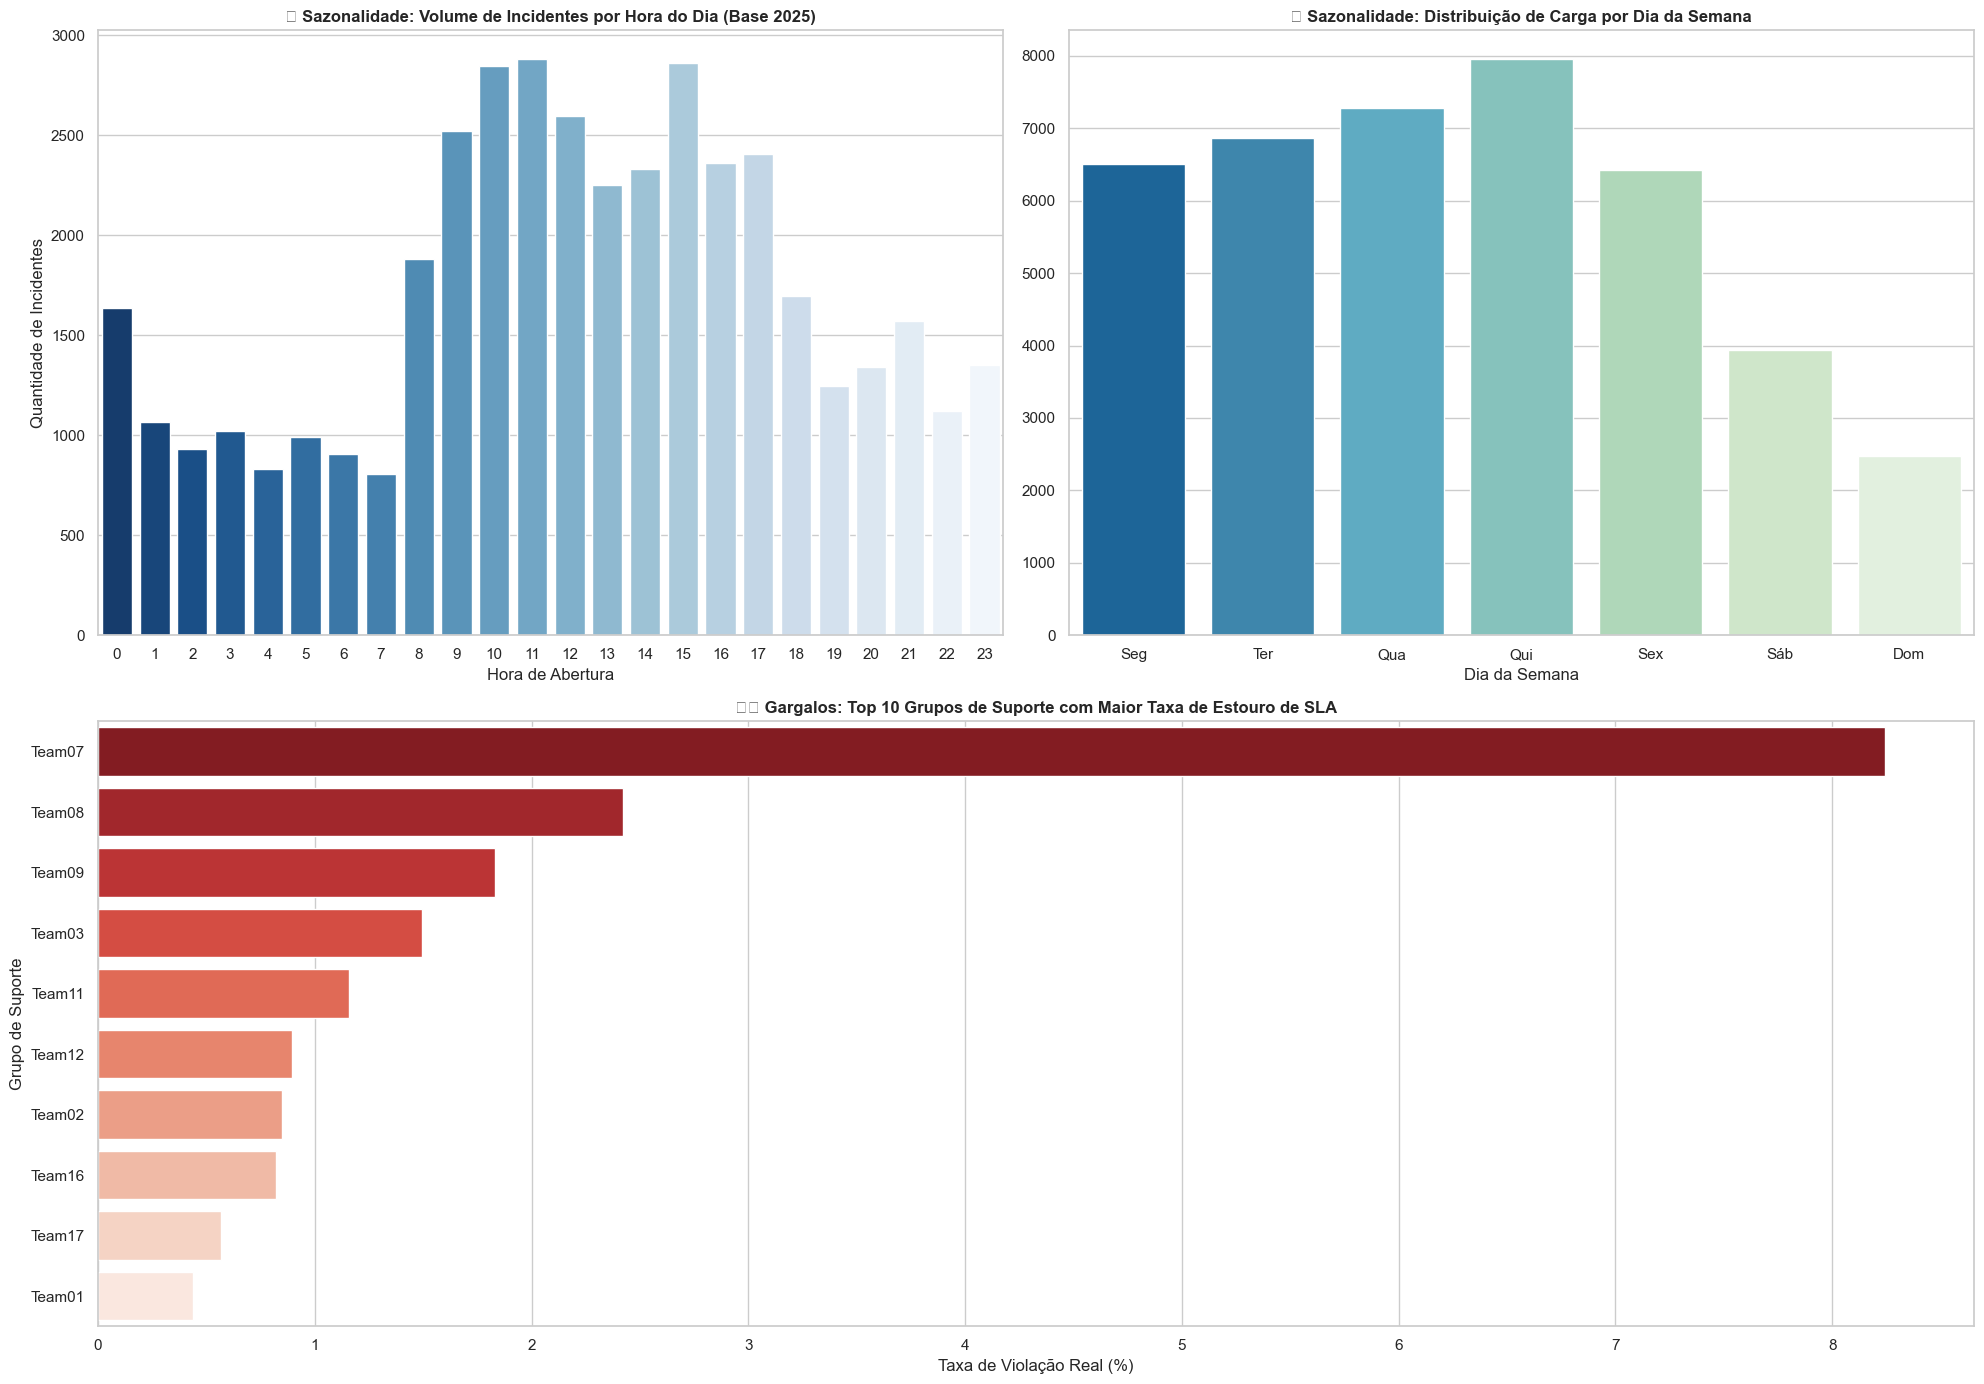


📈 Hipótese de Impacto: Evolução Mensal da Taxa de Violação:
-----------------------------------------------------------------
         Total_Incidentes  Violados  Taxa_Violacao_%
Ano_Mes                                             
2025-01              3713        23         0.619445
2025-02              3546        25          0.70502
2025-03              3585        19         0.529986
2025-04              3201        12         0.374883
2025-05              3323        21         0.631959
2025-06              3548        31         0.873732
2025-07              3441        29         0.842778
2025-08              3949        17         0.430489
2025-09              3723        11         0.295461
2025-10              4053        11         0.271404
2025-11              3016        21         0.696286
2025-12              2343        18         0.768246
-----------------------------------------------------------------


In [27]:
print("⏳ Filtrando a base Silver definitiva (Pós-2025 + Esforço Real)...")
# Aplicando os cortes consolidados na nossa análise gráfica anterior
df_silver = df[(df['Aberto'] >= '2025-01-01') & (df['Exige_Intervencao'] == True)].copy()

# Garantindo a existência do Target Consolidado
if 'Target_Risco_SLA' not in df_silver.columns:
    df_silver['Target_Risco_SLA'] = np.where(df_silver['KPI_Status_Int'] == 1, 1, 0)

# ==============================================================================
# ENGENHARIA TEMPORAL PARA AS HIPÓTESES
# ==============================================================================
df_silver['Hora_Abertura'] = df_silver['Aberto'].dt.hour
df_silver['Dia_Semana_Num'] = df_silver['Aberto'].dt.dayofweek
df_silver['Ano_Mes'] = df_silver['Aberto'].dt.strftime('%Y-%m') # Formato string seguro para Parquet

dias_map = {0: 'Seg', 1: 'Ter', 2: 'Qua', 3: 'Qui', 4: 'Sex', 5: 'Sáb', 6: 'Dom'}
df_silver['Dia_Semana_Nome'] = df_silver['Dia_Semana_Num'].map(dias_map)

# ==============================================================================
# PLOTS DAS HIPÓTESES DE NEGÓCIO
# ==============================================================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 14))

# [Hipótese 1] Sazonalidade por Hora do Dia
plt.subplot(2, 2, 1)
sns.countplot(x='Hora_Abertura', data=df_silver, palette='Blues_r')
plt.title('📊 Sazonalidade: Volume de Incidentes por Hora do Dia (Base 2025)', fontsize=12, fontweight='bold')
plt.xlabel('Hora de Abertura')
plt.ylabel('Quantidade de Incidentes')

# [Hipótese 1] Sazonalidade por Dia da Semana
plt.subplot(2, 2, 2)
order_dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
sns.countplot(x='Dia_Semana_Nome', data=df_silver, order=order_dias, palette='GnBu_r')
plt.title('📅 Sazonalidade: Distribuição de Carga por Dia da Semana', fontsize=12, fontweight='bold')
plt.xlabel('Dia da Semana')
plt.ylabel('')

# [Hipótese 2] Gargalos por Grupo de Suporte (Taxa de Estouro de SLA)
plt.subplot(2, 1, 2)
grupo_col = 'Grupo_designado' if 'Grupo_designado' in df_silver.columns else 'Grupo'
df_silver[grupo_col] = df_silver[grupo_col].fillna('Não Classificado')

analise_grupos = df_silver.groupby(grupo_col).agg(
    Total_Chamados=('Duração', 'count'),
    Violacoes=('Target_Risco_SLA', 'sum')
).reset_index()

analise_grupos['Taxa_Violacao_%'] = (analise_grupos['Violacoes'] / analise_grupos['Total_Chamados']) * 100
# Filtrando apenas grupos com volume expressivo (>50 chamados) para robustez estatística
gargalos_top10 = analise_grupos[analise_grupos['Total_Chamados'] > 50].sort_values(by='Taxa_Violacao_%', ascending=False).head(10)

sns.barplot(x='Taxa_Violacao_%', y=grupo_col, data=gargalos_top10, palette='Reds_r')
plt.title('⚠️ Gargalos: Top 10 Grupos de Suporte com Maior Taxa de Estouro de SLA', fontsize=12, fontweight='bold')
plt.xlabel('Taxa de Violação Real (%)')
plt.ylabel('Grupo de Suporte')

plt.tight_layout()
plt.show()

# [Hipótese 3] Tendência Mensal e Projeção de Risco
print("\n📈 Hipótese de Impacto: Evolução Mensal da Taxa de Violação:")
print("-" * 65)
tendencia_mensal = df_silver.groupby('Ano_Mes').agg(
    Total_Incidentes=('Duração', 'count'),
    Violados=('Target_Risco_SLA', 'sum')
)
tendencia_mensal['Taxa_Violacao_%'] = (tendencia_mensal['Violados'] / tendencia_mensal['Total_Incidentes']) * 100
print(tendencia_mensal)
print("-" * 65)

## 🎯 Formulação e Validação de Hipóteses de Negócio (Camada Silver)

Após o saneamento cronológico e o isolamento do esforço real pós-2025, os testes estatísticos converteram nossas suposições em fatos operacionais mensuráveis. Abaixo está a documentação oficial dos insights gerados para o negócio, prontos para orientar a arquitetura dos nossos modelos preditivos.

---

### 1. Sazonalidade Intra-diária e Semanal: Onde estão as janelas de sobrecarga?

* **O que os dados revelaram (Hora do Dia):** O fluxo de incidentes humanos não é linear. Há um claro comportamento bimodal com dois picos principais de abertura de chamados: entre **10:00 e 11:00** na parte da manhã, e às **15:00** na parte da tarde. Além disso, há um comportamento anômalo e intrigante à **meia-noite (00:00)**, que apresenta um volume significativamente superior às demais horas da madrugada.
* **O que os dados revelaram (Dia da Semana):** A carga de esforço cresce gradualmente ao longo da semana, atingindo o seu ápice absoluto na **Quinta-feira**, aproximando-se da marca de 8.000 incidentes. O volume cai drasticamente no final de semana, com o Domingo registrando a menor carga operacional da escala.
* **Impacto no Negócio & IA:** O pico da meia-noite levanta a hipótese de rotinas automáticas, deploys ou processamentos em lote (*batch*) que falham e geram esforço humano imediato. Para o **Modelo 1 (Forecast)**, o comportamento cíclico intra-diário e o pico das quintas-feiras serão os principais padrões sazonais capturados pelo algoritmo para prever a carga de trabalho futura.

---

### 2. Análise de Gargalos: Quais grupos retêm a maior taxa de violação?

* **O que os dados revelaram:** O mapeamento das taxas reais de estouro de SLA (utilizando o nosso target corrigido de compliance) apontou o **Team07** como o gargalo mais crítico e isolado de toda a operação de TI. Este grupo apresenta uma taxa de violação superior a **8%**, mais do que o triplo do segundo colocado (**Team08**, com aproximadamente 2.5%) e do terceiro (**Team09**, com 1.8%).
* **Impacto no Negócio & IA:** O **Team07** é um ponto único de falha no contrato de prestação de serviços. Uma taxa de estouro de 8% em um grupo específico exige uma auditoria interna de processos: pode indicar subdimensionamento crônico da equipe, alta complexidade técnica dos ativos sob sua responsabilidade ou falta de ferramentas adequadas. Para o **Modelo 2 (Risco de SLA)**, a identificação do grupo de suporte de destino na abertura do chamado atuará como uma das *features* de maior peso estatístico para inferir o risco de multa.

---
#### 3. Hipótese de Impacto: Análise de Tendência Mensal e Desbalanceamento Crítico

A consolidação do histórico mês a mês ao longo de 2025 revelou o comportamento macro da operação e impôs uma diretriz matemática severa para a fase de modelagem:

* **Dinâmica de Calendário Operacional:** O volume de incidentes de Esforço Real mantém uma média estável entre 3.200 e 4.000 chamados mensais. A retração observada em **Dezembro (2.343 chamados)** valida a hipótese de *Change Freeze* (estabilização programada de fim de ano). Os picos de estouro contratual concentram-se em **Junho e Julho (taxas de 0,87% e 0,84%)**, indicando possíveis janelas de defasagem de escala por férias ou manutenções sazonais.
* **O Diagnóstico da Agulha no Palheiro:** A operação demonstra alto controle de qualidade contratual. A taxa consolidada de violação em 2025 é de apenas **~0,57%** (238 violações em 41.441 chamados). 

**Impacto Estratégico na Arquitetura de IA (Feature Engineering & Modelagem):**
1. **Métrica de Avaliação:** Acurácia convencional será totalmente descartada como métrica de sucesso para o modelo de Risco (SLA). Avaliaremos o modelo estritamente por **Recall** e **F1-Score** na classe 1 (Violado), garantindo que a IA seja penalizada caso ignore os raros eventos de estouro.
2. **Mitigação Estatística:** Na preparação das matrizes, implementaremos técnicas de balanceamento de classes (como ajuste de hiperparâmetros de penalidade ou reamostragem), impedindo o viés de predição majoritária.

### 4. Tendência de Impacto e Próximos Passos (Transição para a Camada Gold)

Com estes diagnósticos consolidados, a série temporal limpa e o comportamento dos grupos mapeados, mitigamos o risco de treinar os algoritmos com dados distorcidos. A base foi congelada e persistida no formato **Parquet** (`df_silver_2025.parquet`), garantindo a preservação total dessas componentes temporais e categóricas.

No próximo caderno, **`03_feature_engineering.ipynb`**, utilizaremos estes marcos analíticos para fracionar o dataset em nossas três matrizes de entrega:
1. **Agrupamento Temporal Diário** para a previsão de volume.
2. **Matriz de Atendimento Inicial** (removendo dados de fechamento) para o modelo de risco.
3. **Matriz de Perfis Operacionais Escalados** para o algoritmo de clusterização.

In [ ]:

# 1. Preparação da Métrica de Auditoria
df['Duracao_Horas'] = df['Duração'] / 3600

# 2. Definição da Função de Auditoria Blindada contra <NA>
def auditar_kpi_seguro(row):
    # Se a prioridade ou a duração forem nulas, não dá para auditar
    if pd.isna(row['Prioridade']) or pd.isna(row['Duracao_Horas']):
        return 'Dados Incompletos (Sem Prio/Duração)'
    
    prio = row['Prioridade']
    duracao = row['Duracao_Horas']
    kpi = row['KPI_Violado?']
    
    # Tratamento seguro para os estados do KPI (evitando o erro de NA ambíguo)
    is_kpi_nao = (kpi == 'Não') if not pd.isna(kpi) else False
    is_kpi_sim = (kpi == 'Sim') if not pd.isna(kpi) else False
    is_kpi_nulo = pd.isna(kpi)

    # Regra para P1 e P2 (4h)
    if prio in ['1 - Crítica', '2 - Alta']:
        if duracao > 4 and is_kpi_nao:
            return 'Falso Negativo (Violou mas não marcou)'
        if duracao <= 4 and is_kpi_sim:
            return 'Falso Positivo (Dentro do tempo mas marcou violação)'
        if is_kpi_nulo:
            return 'Inconsistência (Crítico sem registro de KPI)'
            
    # Regra para P3 (12h)
    elif prio == '3 - Moderada':
        if duracao > 12 and is_kpi_nao:
            return 'Falso Negativo (Violou mas não marcou)'
        if duracao <= 12 and is_kpi_sim:
            return 'Falso Positivo (Dentro do tempo mas marcou violação)'
        if is_kpi_nulo:
            return 'Inconsistência (Moderado sem registro de KPI)'
            
    # Regra para P4 e P5 (Não deveriam ter KPI)
    elif prio in ['4 - Baixa', '5 - Planejada']:
        if is_kpi_sim:
            return 'Erro de Elegibilidade (P4/P5 com KPI)'
            
    return 'OK'

# 3. Execução da Auditoria apenas no Esforço Real
df_auditoria = df[df['Exige_Intervencao'] == True].copy()
df_auditoria['Status_Compliance'] = df_auditoria.apply(auditar_kpi_seguro, axis=1)

# 4. Resumo da Auditoria
resumo_compliance = df_auditoria['Status_Compliance'].value_counts()

print("🔍 Resultado da Auditoria de Compliance (Esforço Real):")
print("-" * 50)
print(resumo_compliance)
print("-" * 50)

# 5. Alerta de Inconsistências
erros = df_auditoria[df_auditoria['Status_Compliance'] != 'OK']
if len(erros) > 0:
    print(f"⚠️ Alerta: Identificados {len(erros)} registros com problemas de compliance.")
else:
    print("✅ Sucesso: O flag de KPI reflete perfeitamente a duração matemática.")


🔍 Resultado da Auditoria de Compliance (Esforço Real):
--------------------------------------------------
Status_Compliance
OK                                              37941
Inconsistência (Crítico sem registro de KPI)     4229
Name: count, dtype: int64
--------------------------------------------------
⚠️ Alerta: Identificados 4229 registros com problemas de compliance.


In [33]:
print("🛠️ Iniciando Tratamento Estratégico de Nulos (Camada Silver)...")
print("-" * 60)

# 1. Filtragem da janela temporal e esforço real
df_silver_2025 = df[(df['Aberto'] >= '2025-01-01') & (df['Exige_Intervencao'] == True)].copy()

# 2. Tratamento do Grupo 1: Ciclo de vida e Hierarquia (Garantindo strings e tratamento seguro)
df_silver_2025['Incidente_Pai'] = df_silver_2025['Incidente_Pai'].fillna('Independente')
df_silver_2025['Código_de_fechamento'] = df_silver_2025['Código_de_fechamento'].fillna('Não Encerrado')
df_silver_2025['Solução'] = df_silver_2025['Solução'].fillna('Sem Descrição de Solução')

# 3. Tratamento do Grupo 2 e 3: Categoriais faltantes de preenchimento
df_silver_2025['Subcategoria'] = df_silver_2025['Subcategoria'].fillna('Não Informada')
df_silver_2025['Item_de_configuração'] = df_silver_2025['Item_de_configuração'].fillna('Não Cadastrado')

# 4. Campos de Data de fechamento que podem estar nulos (Chamados ainda abertos no final do período)
# Usamos uma data marco fictícia (NaT) ou mantemos nativo do Pandas, preenchendo apenas texto auxiliar se necessário
df_silver_2025['Resolvido'] = df_silver_2025['Resolvido'].fillna(pd.NaT)

print("✅ Todos os nulos categóricos e estruturais foram tratados por regra de negócio!")
print(f"Total de linhas prontas: {len(df_silver_2025)}")
print("-" * 60)

🛠️ Iniciando Tratamento Estratégico de Nulos (Camada Silver)...
------------------------------------------------------------
✅ Todos os nulos categóricos e estruturais foram tratados por regra de negócio!
Total de linhas prontas: 41441
------------------------------------------------------------


In [29]:
print("🎯 Consolidando a Variável Alvo (Target_Risco_SLA)...")

# 1. Base padrão: Se o sistema marcou formalmente KPI_Status_Int = 1, é 1 (Violou). Se marcou 0, é 0 (No prazo).
df['Target_Risco_SLA'] = np.where(df['KPI_Status_Int'] == 1, 1, 0)

# 2. Correção cirúrgica dos 38 casos de P2 (Omissos Sistêmicos onde KPI_Status_Int era -1)
# Se passou de 4 horas na Prioridade 2 e estava em branco, forçamos a marcação como Violado (1)
condicao_p2_estourado = (df['KPI_Status_Int'] == -1) & (df['Prioridade_Num'] == 2) & (df['Duracao_Horas'] > 4)
df.loc[condicao_p2_estourado, 'Target_Risco_SLA'] = 1

# 3. Exclusão de Risco Regulatória: Se possui pai ou não exige intervenção, o risco contratual é ZERO
df.loc[(df['Possui_Pai'] == 1) | (df['Exige_Intervencao'] == False), 'Target_Risco_SLA'] = 0

print("✅ Coluna 'Target_Risco_SLA' integrada com sucesso!")
print(df['Target_Risco_SLA'].value_counts())

🎯 Consolidando a Variável Alvo (Target_Risco_SLA)...
✅ Coluna 'Target_Risco_SLA' integrada com sucesso!
Target_Risco_SLA
0    122293
1       250
Name: count, dtype: int64


C:\Users\LucasBittencourt\AppData\Local\Temp\ipykernel_19040\1324796727.py:27: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
d:\Projetos\AWS_Portifolio\Projeto aws\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


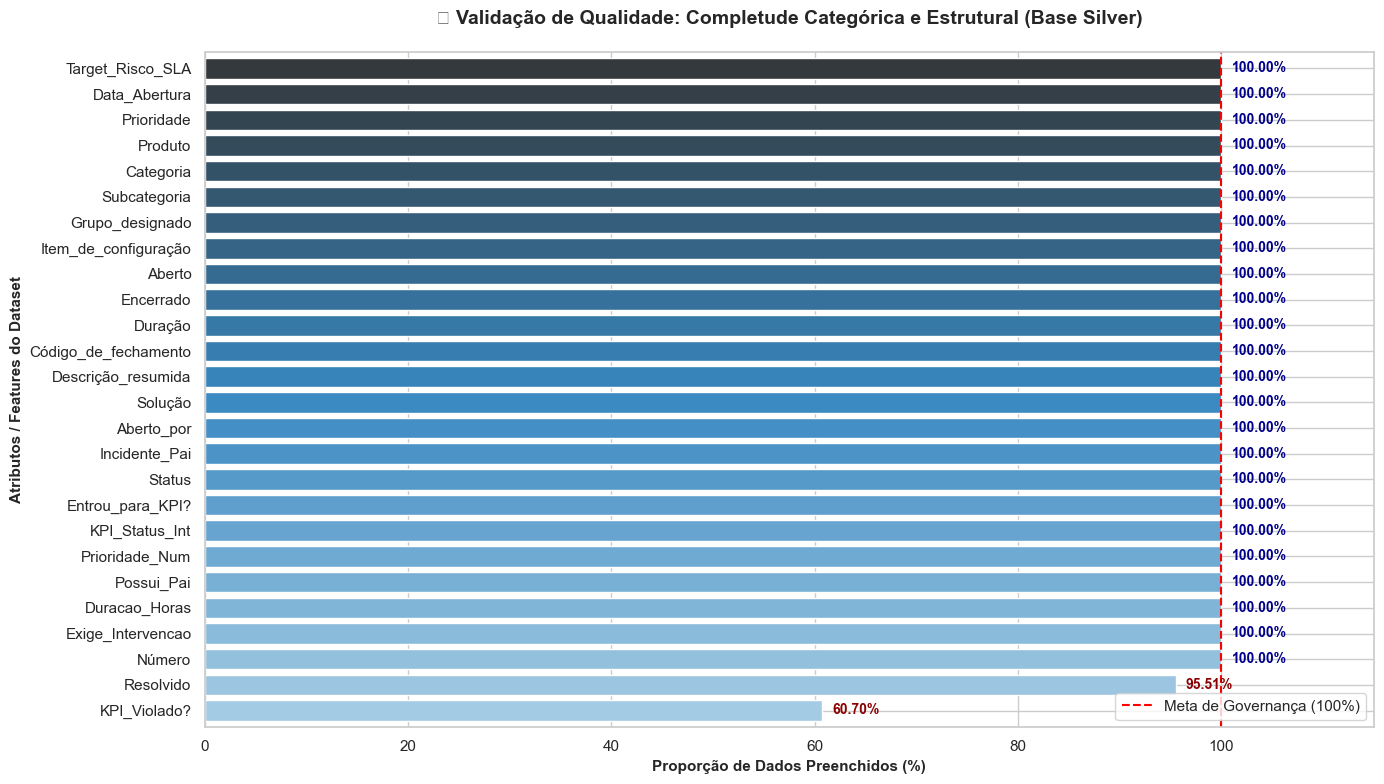

In [34]:
# Configurando o estilo visual para o padrão do projeto
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

# 1. Calculando a porcentagem de dados preenchidos na base tratada (df_silver_2025)
completude = (1 - (df_silver_2025.isnull().sum() / len(df_silver_2025))) * 100
completude_ordenada = completude.sort_values()

# 2. Plotando o gráfico horizontal com uma paleta que destaca o sucesso (médios/altos em tons de azul)
colors = sns.color_palette("Blues_d", len(completude_ordenada))
ax = completude_ordenada.plot(kind='barh', color=colors, width=0.8)

# 3. Adicionando os rótulos com a porcentagem exata na ponta de cada barra
for i, v in enumerate(completude_ordenada):
    ax.text(v + 1, i - 0.15, f"{v:.2f}%", fontsize=10, fontweight='bold', 
            color='darkblue' if v == 100 else 'darkred')

# 4. Ajustes de layout e linha de meta (100% de preenchimento controlado)
plt.title("🎯 Validação de Qualidade: Completude Categórica e Estrutural (Base Silver)", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Proporção de Dados Preenchidos (%)", fontsize=11, fontweight='bold')
plt.ylabel("Atributos / Features do Dataset", fontsize=11, fontweight='bold')
plt.xlim(0, 115) # Margem para os textos não cortarem
plt.axvline(x=100, color='red', linestyle='--', linewidth=1.5, label='Meta de Governança (100%)')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [35]:
import awswrangler as wr

# 1. Filtragem definitiva da base Silver (Apenas pós-2025 + Esforço Real)
df_silver_2025 = df[(df['Aberto'] >= '2025-01-01') & (df['Exige_Intervencao'] == True)].copy()

# 2. Definição do caminho correto na pasta SILVER do S3
s3_silver_path = "s3://aiops-locaweb-datalake-2026/silver/incidents_silver_2025.parquet"

# 3. Escrita otimizada no S3 usando AWS Wrangler
wr.s3.to_parquet(
    df=df_silver_2025,
    path=s3_silver_path,
    dataset=True,
    mode="overwrite",
    index=False
)

print(f"✅ Sucesso! Camada Silver salva em Parquet no S3: {s3_silver_path}")
print(f"📊 Total de registros persistidos na Silver: {len(df_silver_2025)}")

✅ Sucesso! Camada Silver salva em Parquet no S3: s3://aiops-locaweb-datalake-2026/silver/incidents_silver_2025.parquet
📊 Total de registros persistidos na Silver: 41441
